# 1장 실습 — 과제 정의와 기준선 측정

캡스톤의 첫 줄은 코드가 아니라 **계약**이다. 이 장이 정하는 것 셋이다.

1. **과제** — 무엇을 성공이라 부를 것인가
2. **로그 스키마** — 판마다 무엇을 적을 것인가
3. **수용 기준** — 어느 수를 넘어야 다음 단계로 가는가

셋 다 뒤의 열일곱 장이 읽는다. 4권 16장이 「로그 스키마가 게이트보다 먼저다」로 끝났고, 이 노트북이 그 문장에서 시작한다.

그리고 이 장은 한 가지를 더 한다. **이 과제가 정말 노트북에서 돌아가는지 재는 것**이다. 기획이 실측을 이기지 못한다.

실행 시간은 CPU에서 8분 안팎이다. 강화학습을 여섯 번(시드 셋 × 종료 규칙 둘) 돌리는 것이 대부분이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


## 로그 스키마

판마다 한 줄이다. 열은 일곱 개이고, 각각 뒤의 어느 장이 쓸지를 적어 둔다.

| 열 | 뜻 | 쓰는 곳 |
|---|---|---|
| cond | 평가 조건 (명목 / 배포) | 전 장 |
| version | 정책·데이터 판번호 (v0, bc-dart, n32 …) | 9 · 17장 |
| seed | 학습 시드 | 1 · 16장 |
| kind | 부품 종류 (A / B) | 3 · 5장 |
| success | 적재함에 들어갔는가 | 전 장 |
| wrong | 반대 칸에 들어갔는가 | 15 · 17장 |
| steps | 주기 — 몇 스텝에 끝났는가 | 13 · 17장 |


In [5]:
COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """판마다 한 줄을 남긴다 — 이것이 이 책의 로그다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def summarize(rows, name):
    n = len(rows)
    ok = sum(r[4] for r in rows)
    wr = sum(r[5] for r in rows)
    st = np.array([r[6] for r in rows])
    lo, hi = wilson(ok, n)
    return (name, ok / n, lo, hi, wr / n, np.median(st), n)


def table(res):
    h = (pad("", 14) + pad("성공률", 9, True)
         + pad("95% 구간", 16, True) + pad("오배출", 9, True)
         + pad("주기 p50", 10, True) + pad("판", 7, True))
    print(h)
    for nm, r, lo, hi, w, md, n in res:
        print(pad(nm, 14) + pad(f"{r:.3f}", 9, True)
              + pad(f"[{lo:.2f}, {hi:.2f}]", 16, True)
              + pad(f"{w:.3f}", 9, True)
              + pad(f"{md:.0f}", 10, True)
              + pad(f"{n}", 7, True))


rng0 = np.random.default_rng(0)
rnd = lambda e: rng0.uniform(-1, 1, (e.n, 2)).astype(np.float32)
t0 = time.time()
R = rollout(rnd, "명목", ver="random")
print(f"무작위 정책 {len(R)} 판  ({time.time() - t0:.0f}s)\n")
print(" · ".join(COLS))
for r in R[:4]:
    print(" · ".join(str(x) for x in r))

무작위 정책 450 판  (5s)

cond · version · seed · kind · success · wrong · steps
명목 · random · 0 · A · 0 · 0 · 110
명목 · random · 0 · B · 0 · 0 · 110
명목 · random · 0 · B · 0 · 0 · 110
명목 · random · 0 · B · 0 · 0 · 110


## 대본 전문가 정책

1부의 시연은 손으로 쓴 비례 제어기가 만든다. 3권 6장의 서보를 분류 셀로 옮긴 것이고, 종류에 따라 목표만 갈린다.

In [6]:
def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """부품 뒤로 돌아가 적재함 방향으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


t0 = time.time()
LOG = []
R = rollout(rnd, "명목", ver="random")
LOG += R
RES = [summarize(R, "무작위 명목")]
for c in COND:
    R = rollout(servo, c, ver="expert")
    LOG += R
    RES.append(summarize(R, f"전문가 {c}"))
print(f"({time.time() - t0:.0f}s)\n")
table(RES)

(21s)

                 성공률        95% 구간   오배출  주기 p50     판
무작위 명목       0.000    [0.00, 0.01]    0.000       110    450
전문가 명목       1.000    [1.00, 1.00]    0.000        45   1025
전문가 배포       1.000    [1.00, 1.00]    0.000        51    892


## 에피소드 종료 조건

과제 정의에 눈에 띄지 않는 결정이 하나 숨어 있다. **부품이 적재함에 들어간 뒤에도 판을 계속 돌릴 것인가.**

앞 네 권은 판을 늘 110스텝 고정으로 돌렸다. 이 캡스톤은 성공하면 끝낸다. 실기로 옮기면 「다음 부품이 들어온다」는 뜻이고, 사소한 차이로 보인다.

두 규칙을 각각 세 시드로 학습시켜 비교한다. 강화학습 설정은 3권 8장 그대로다.

In [7]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [8]:
def samp(pol):
    def f(env):
        ot = torch.from_numpy(env.obs())
        with torch.no_grad():
            return pol.dist(ot).sample().numpy()
    return f


SEEDS = (0, 1, 2)


def no_early(self, a):
    """비교군 — 성공해도 110스텝을 채운다"""
    r = np.zeros(self.n, np.float32)
    dn = np.zeros(self.n, np.float32)
    sc = []
    for i, d in enumerate(self.d):
        d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
        for _ in range(self.sub):
            mujoco.mj_step(self.m, d)
        db = np.linalg.norm(d.qpos[0:2] - self.g[i])
        dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                + (.3 if db < GOAL_R else 0.))
        self.db[i], self.dp[i] = db, dp
        self.t[i] += 1
        if self.t[i] >= EP:
            dn[i] = 1.
            other = bin_xy(1 - self.k[i])
            wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
            sc.append((int(db < GOAL_R), int(wrong), int(self.t[i]),
                       int(self.k[i])))
            self.reset(i)
    return r, dn, sc


EARLY = Cell.step
POL, TT, LATE = {}, {}, {}
for sd in SEEDS:
    t0 = time.time()
    POL[sd] = train_rl(seed=sd)
    TT[sd] = time.time() - t0
    Cell.step = no_early
    LATE[sd] = train_rl(seed=sd)
    Cell.step = EARLY
    print(f"시드 {sd} 끝  (규칙당 {TT[sd]:.0f}s)", flush=True)

print()
RL, RL0 = [], []
for sd in SEEDS:
    rows = rollout(samp(POL[sd]), "명목", tag=sd)
    LOG += rows
    RL.append(summarize(rows, f"성공 시 종료 {sd}"))
    rows = rollout(samp(LATE[sd]), "명목", tag=sd, ver="v0-fill")
    RL0.append(summarize(rows, f"시간 채움 {sd}"))
table(RL + RL0)
print()
avg = np.mean(list(TT.values()))
tot = 2 * sum(TT.values()) / 60
print(f"학습 {avg:.0f}s × {len(SEEDS)} 시드 × 2 규칙 = {tot:.1f}분")

시드 0 끝  (규칙당 68s)


시드 1 끝  (규칙당 66s)


시드 2 끝  (규칙당 67s)


                 성공률        95% 구간   오배출  주기 p50     판
성공 시 종료 0    0.999    [1.00, 1.00]    0.000        20   2434
성공 시 종료 1    1.000    [1.00, 1.00]    0.000        20   2169
성공 시 종료 2    0.989    [0.98, 0.99]    0.000        20   2290
시간 채움 0       0.347    [0.31, 0.39]    0.000       110    472
시간 채움 1       0.899    [0.88, 0.92]    0.000        38    985
시간 채움 2       0.659    [0.62, 0.70]    0.019        71    539

학습 67s × 3 시드 × 2 규칙 = 6.7분


## 종료 조건의 효과

이 표가 이 장의 결과다. **판을 언제 끝내느냐가 알고리즘보다 크게 작용한다.**

시간을 채우는 쪽에서는 궤적의 대부분이 「이미 끝났고 가만히 있는」 스텝이다. 보상은 거의 0이고, 정책이 배워야 할 구간은 앞쪽 일부뿐이다. 성공하면 끝내는 쪽은 그 희석이 없다.

**과제 정의가 알고리즘보다 먼저다.** 하이퍼파라미터를 훑기 전에 볼 곳이 여기다.

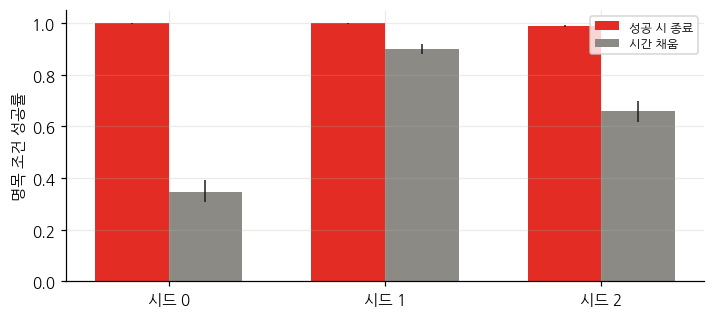

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(len(SEEDS))
w = .34
for i, (rs, col, lab) in enumerate(
        ((RL, RED, "성공 시 종료"), (RL0, GREY, "시간 채움"))):
    v = [r[1] for r in rs]
    lo = [max(r[1] - r[2], 0.) for r in rs]
    hi = [max(r[3] - r[1], 0.) for r in rs]
    ax.bar(x + (i - .5) * w, v, w, yerr=[lo, hi], color=col,
           label=lab, error_kw=dict(lw=1, ecolor=INK))
ax.set_xticks(x)
ax.set_xticklabels([f"시드 {s}" for s in SEEDS])
ax.set_ylabel("명목 조건 성공률")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

막대에 붙은 것은 Wilson 95% 구간이다. 좁다 — 시드마다 판을 수백에서 이천여 번 돌렸기 때문이다.

그런데 그 구간이 재는 것은 **평가의 불확실성**이지 **학습의 불확실성**이 아니다. 시드 사이의 차이는 구간과 무관하게 남고 판을 더 돌려도 줄지 않는다. 그래서 시드를 여러 개 쓴다.

## 배포 조건 기준선

명목 조건의 수만으로는 아무것도 정할 수 없다는 것이 4권의 결론이었다. 기준선을 배포 조건에서 다시 잰다.

In [10]:
BASE = [RES[1], RES[2]]
for sd in SEEDS:
    rows = rollout(samp(POL[sd]), "배포", tag=sd)
    LOG += rows
    BASE.append(summarize(rows, f"RL 배포 {sd}"))
table(BASE)

                 성공률        95% 구간   오배출  주기 p50     판
전문가 명목       1.000    [1.00, 1.00]    0.000        45   1025
전문가 배포       1.000    [1.00, 1.00]    0.000        51    892
RL 배포 0         0.793    [0.77, 0.82]    0.002        28    997
RL 배포 1         0.885    [0.87, 0.90]    0.000        24   1178
RL 배포 2         0.714    [0.68, 0.74]    0.001        23    923


## 수용 기준

이 장이 남기는 계약을 적는다. 뒤의 열일곱 장이 이 규칙을 따른다.

In [11]:
import os
import csv
import json

for dd in ("policy", "report"):
    os.makedirs(dd, exist_ok=True)
torch.save(POL[0], "policy/v0.pt")
with open("report/ch01_log.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(COLS)
    w.writerows(LOG)
CONTRACT = {"task": "sorting_cell", "early_termination": True,
            "conditions": COND, "eval_cells": 150, "eval_steps": 330,
            "min_episodes": 200,
            "seeds": len(SEEDS), "columns": COLS,
            "interval": "wilson95"}
with open("report/contract.json", "w") as f:
    json.dump(CONTRACT, f, ensure_ascii=False, indent=1)
print("남긴 산출물")
print("  policy/v0.pt          기준 정책 (2장이 읽는다)")
print(f"  report/ch01_log.csv   판별 로그 {len(LOG):,}줄")
print("  report/contract.json  수용 기준 (전 장이 읽는다)")
print()
print("캡스톤 수용 기준")
print()
print(pad("항목", 16) + "값")
print(pad("과제", 16) + "평면 분류 셀 — 두 적재함, 성공 시 판 종료")
print(pad("평가 조건", 16) + " · ".join(COND) + " 두 곳 모두")
print(pad("평가 예산", 16) + "조건마다 셀 150개 × 330스텝")
print(pad("", 16) + "판 수는 주기에 따라 다르다 — 최소 200판")
print(pad("", 16) + "Wilson 95% 구간을 함께 적는다")
print(pad("학습 시드", 16) + f"{len(SEEDS)}개 이상 · 범위 동반")
print(pad("보고 열", 16) + " · ".join(COLS))
print(pad("CPU 예산", 16) + f"정책 {avg:.0f}s · 전체 {tot:.1f}분")
print()
print("기준선")
print()
table(BASE)

남긴 산출물
  policy/v0.pt          기준 정책 (2장이 읽는다)
  report/ch01_log.csv   판별 로그 12,358줄
  report/contract.json  수용 기준 (전 장이 읽는다)

캡스톤 수용 기준

항목            값
과제            평면 분류 셀 — 두 적재함, 성공 시 판 종료
평가 조건       명목 · 배포 두 곳 모두
평가 예산       조건마다 셀 150개 × 330스텝
                판 수는 주기에 따라 다르다 — 최소 200판
                Wilson 95% 구간을 함께 적는다
학습 시드       3개 이상 · 범위 동반
보고 열         cond · version · seed · kind · success · wrong · steps
CPU 예산        정책 67s · 전체 6.7분

기준선

                 성공률        95% 구간   오배출  주기 p50     판
전문가 명목       1.000    [1.00, 1.00]    0.000        45   1025
전문가 배포       1.000    [1.00, 1.00]    0.000        51    892
RL 배포 0         0.793    [0.77, 0.82]    0.002        28    997
RL 배포 1         0.885    [0.87, 0.90]    0.000        24   1178
RL 배포 2         0.714    [0.68, 0.74]    0.001        23    923


## 정리

**과제가 풀린다는 것을 먼저 확인했다.** 대본 전문가가 두 조건 모두에서 성공한다. 1부가 시연을 모을 수 있다는 뜻이고, 이것이 데이터 수집의 전제다.

**로그 스키마를 일곱 열로 고정했다.** 성공률 하나로는 느리게 성공한 것과 엉뚱한 칸에 넣은 것을 구별할 수 없다. 주기와 오배출 열이 그래서 있다.

**같은 코드가 시드에 따라 갈린다.** 이것이 이 장의 실측이고, 이 캡스톤의 첫 규약을 만들었다 — **정책 수치는 시드 여러 개로 내고 범위를 함께 적는다.**

**그리고 이 규약이 나머지 열일곱 장의 비용을 정한다.** 한계 수익 표의 모든 행이 시드 수만큼 비싸진다. 그 비용을 1장에서 알고 시작하는 것과 12장에서 알게 되는 것은 다르다.

2장은 시연을 모으는 세 가지 길을 같은 예산에서 맞세운다.